# Foundation Models Comparison: TimesFM 2.5 vs Chronos 2This notebook provides a comprehensive comparison of two state-of-the-art foundation models for time series forecasting:- **TimesFM 2.5** (Google Research): Decoder-only transformer pre-trained on 100B+ time points- **Chronos 2** (Amazon Science): T5-based model with language model techniquesBoth models support **zero-shot forecasting** - making predictions without any training!**What you'll learn:**- How each model performs on the same data- Key differences in capabilities and design- When to use each model- Performance characteristics (speed, accuracy)

## Installation Requirements

Both models have specific installation requirements:

```bash
# For TimesFM
git clone https://github.com/google-research/timesfm.git
cd timesfm
pip install -e ".[torch]"

# For Chronos 2
pip install 'darts[chronos]'
# or
pip install chronos-forecasting>=2.0.0
```

## Imports

In [15]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.datasets import AirPassengersDataset, EnergyDataset
from darts.models import TimesFMModel, ChronosModel, ExponentialSmoothing
from darts.metrics import mape, rmse

## Visualization Utilities

We'll define a helper function for beautiful probabilistic forecast visualization.

In [16]:
def plot_probabilistic_forecasts(    forecasts,    intervals=[50, 75, 90, 95],    alphas=[0.5, 0.35, 0.2, 0.1],    colors=None,    labels=None,    ax=None,    **kwargs):    """    Plot probabilistic forecasts with color-coded confidence intervals.    Each forecast gets one base color with:    - Median: Solid line (alpha=1.0)    - Narrower intervals: Higher alpha (more opaque)    - Wider intervals: Lower alpha (more transparent)    Parameters    ----------    forecasts : TimeSeries, dict, or list        Single forecast or list of forecasts to plot.        - TimeSeries: Must have num_samples > 1        - dict: Pre-computed quantiles like {0.05: ts, 0.5: ts, 0.95: ts}    intervals : list, default=[50, 75, 90, 95]        Confidence intervals to plot (must be sorted ascending)    alphas : list, default=[0.5, 0.35, 0.2, 0.1]        Alpha values for each interval (narrowest to widest)    colors : list, optional        Colors for each forecast. If None, use matplotlib default cycle.    labels : list, optional        Labels for legend. If None, auto-generate.    ax : matplotlib.axes.Axes, optional        Axis to plot on. If None, create new figure.    **kwargs        Additional arguments passed to TimeSeries.plot()    Returns    -------    ax : matplotlib.axes.Axes        The axis object with plots    Examples    --------    >>> # Single forecast    >>> plot_probabilistic_forecasts(chronos_forecast)    >>> # Compare models    >>> plot_probabilistic_forecasts(    ...     forecasts=[chronos_forecast, timesfm_forecast],    ...     labels=['Chronos 2', 'TimesFM 2.5']    ... )    """    import pandas as pd    # Validation    if len(intervals) != len(alphas):        raise ValueError(f"intervals ({len(intervals)}) and alphas ({len(alphas)}) must have same length")    if not all(0 < i < 100 for i in intervals):        raise ValueError(f"intervals must be between 0 and 100, got {intervals}")    if not all(0 <= a <= 1 for a in alphas):        raise ValueError(f"alphas must be between 0 and 1, got {alphas}")    if intervals != sorted(intervals):        raise ValueError(f"intervals must be sorted ascending, got {intervals}")    # Setup    if ax is None:        fig, ax = plt.subplots(figsize=(12, 6))    # Handle single forecast vs list    forecasts_list = forecasts if isinstance(forecasts, list) else [forecasts]    # Auto-generate labels    if labels is None:        labels = [f"Forecast {i+1}" for i in range(len(forecasts_list))]    # Auto-assign colors    if colors is None:        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']    # Create interval configuration (reversed for plotting widest first)    interval_config = pd.DataFrame({        'interval': intervals,        'alpha': alphas,        'low_q': [(100 - i) / 200 for i in intervals],        'high_q': [1 - (100 - i) / 200 for i in intervals]    }).iloc[::-1]  # Reverse: plot widest → narrowest    # Plot each forecast    for forecast, label, color in zip(forecasts_list, labels, colors):        # Validate forecast type        if isinstance(forecast, dict):            # Dict mode: check for required quantiles            required = {0.5}.union({row['low_q'], row['high_q']} for _, row in interval_config.iterrows())            missing = required - set(forecast.keys())            if missing:                raise ValueError(f"Dict missing quantiles: {sorted(missing)}")        elif isinstance(forecast, TimeSeries):            if forecast.n_samples == 1:                raise ValueError(f"TimeSeries must have num_samples > 1, got {forecast.n_samples}")        else:            raise TypeError(f"forecast must be TimeSeries or dict, got {type(forecast)}")                # Plot intervals (widest to narrowest)        for _, row in interval_config.iterrows():            if isinstance(forecast, dict):                # Dict mode: plot manually                low_ts = forecast[row['low_q']]                high_ts = forecast[row['high_q']]                # Use fill_between via plot API                ax.fill_between(                    low_ts.time_index,                    low_ts.values().flatten(),                    high_ts.values().flatten(),                    color=color,                    alpha=row['alpha'],                    linewidth=0                )            else:                # TimeSeries mode: use built-in API                forecast.plot(                    ax=ax,                    low_quantile=row['low_q'],                    high_quantile=row['high_q'],                    color=color,                    alpha=row['alpha'],                    label='',  # No label for intervals                    **kwargs                )                # Plot median on top (solid line)        if isinstance(forecast, dict):            median = forecast[0.5]        else:            median = forecast.quantile_timeseries(0.5)                median.plot(ax=ax, color=color, label=label, linewidth=2, **kwargs)    # Enhance plot    ax.grid(True, alpha=0.3)    ax.legend(loc='best')    return ax

## Load Test Data

We'll use the classic Air Passengers dataset for our comparison.

Training data: 107 points
Validation data: 37 points


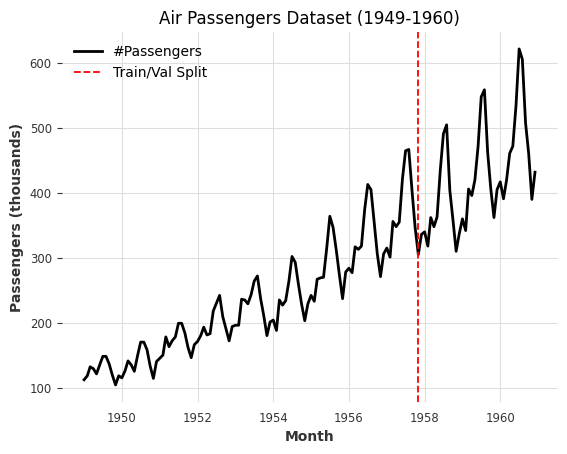

In [17]:
# Load Air Passengers dataset
series = AirPassengersDataset().load()
train, val = series.split_before(0.75)

print(f"Training data: {len(train)} points")
print(f"Validation data: {len(val)} points")

# Visualize
series.plot()
plt.title("Air Passengers Dataset (1949-1960)")
plt.ylabel("Passengers (thousands)")
plt.axvline(x=train.end_time(), color='r', linestyle='--', label='Train/Val Split')
plt.legend()
plt.show()

## 1. Side-by-Side Zero-Shot Forecasting

Let's test both models on the same forecasting task **without any training**.

### TimesFM 2.5 Zero-Shot Forecast

In [18]:
# Initialize TimesFMtimesfm_model = TimesFMModel(zero_shot=True)# Time the predictionstart_time = time.time()timesfm_forecast = timesfm_model.predict(n=len(val), series=train)timesfm_time = time.time() - start_time# Calculate errortimesfm_mape = mape(val, timesfm_forecast)timesfm_rmse = rmse(val, timesfm_forecast)print(f"TimesFM 2.5 Results:")print(f"  MAPE: {timesfm_mape:.2f}%")print(f"  RMSE: {timesfm_rmse:.2f}")print(f"  Inference Time: {timesfm_time:.2f}s")

TimesFM Results:
  MAPE: 8.53%
  RMSE: 50.10
  Inference Time: 2.49s


### Chronos 2 Zero-Shot Forecast

In [19]:
# Initialize Chronos 2
chronos_model = ChronosModel()

# Time the prediction
start_time = time.time()
chronos_forecast = chronos_model.predict(n=len(val), series=train)
chronos_time = time.time() - start_time

# Calculate error
chronos_mape = mape(val, chronos_forecast)
chronos_rmse = rmse(val, chronos_forecast)

print(f"Chronos 2 Results:")
print(f"  MAPE: {chronos_mape:.2f}%")
print(f"  RMSE: {chronos_rmse:.2f}")
print(f"  Inference Time: {chronos_time:.2f}s")

/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Chronos 2 Results:
  MAPE: 5.22%
  RMSE: 26.69
  Inference Time: 5.12s


### Visual Comparison

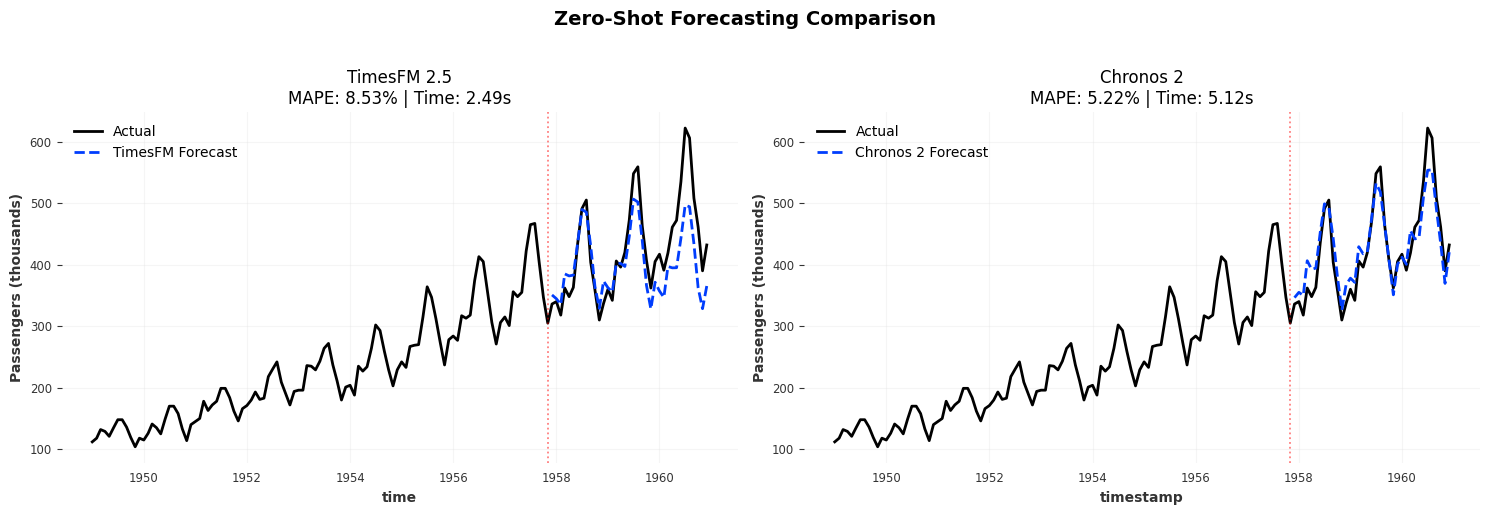

In [20]:
# Plot side-by-side comparisonfig, axes = plt.subplots(1, 2, figsize=(15, 5))# TimesFM plotax = axes[0]series.plot(ax=ax, label="Actual", linewidth=2)timesfm_forecast.plot(ax=ax, label="TimesFM 2.5 Forecast", linewidth=2, linestyle='--')ax.axvline(x=train.end_time(), color='r', linestyle=':', alpha=0.5)ax.set_title(f"TimesFM 2.5\nMAPE: {timesfm_mape:.2f}% | Time: {timesfm_time:.2f}s")ax.set_ylabel("Passengers (thousands)")ax.legend()ax.grid(True, alpha=0.3)# Chronos 2 plotax = axes[1]series.plot(ax=ax, label="Actual", linewidth=2)chronos_forecast.plot(ax=ax, label="Chronos 2 Forecast", linewidth=2, linestyle='--')ax.axvline(x=train.end_time(), color='r', linestyle=':', alpha=0.5)ax.set_title(f"Chronos 2\nMAPE: {chronos_mape:.2f}% | Time: {chronos_time:.2f}s")ax.set_ylabel("Passengers (thousands)")ax.legend()ax.grid(True, alpha=0.3)plt.suptitle("Zero-Shot Forecasting Comparison", fontsize=14, fontweight='bold', y=1.02)plt.tight_layout()plt.show()

### Overlay Comparison

In [21]:
# Create comparison table
comparison_data = {
    'Feature': [
        'Model Family',
        'Architecture',
        'Parameters',
        'Training Data',
        'Max Context Length',
        'Max Forecast Horizon',
        'Patch Size',
        'Multivariate Support',
        'Probabilistic Forecasting',
        'Zero-Shot Capable',
        'Fine-Tuning Support',
        'GPU Acceleration',
        'Installation'
    ],
    'TimesFM 2.5': [
        'Google Research',
        'Decoder-only Transformer',
        '200M / 500M',
        '100B+ time points',
        '16,384 points',
        '256 points',
        '32 points',
        'No (univariate only)',
        'Yes',
        'Yes',
        'Planned (PEFT/LoRA)',
        'Yes (CUDA/MPS)',
        'GitHub + pip install'
    ],
    'Chronos 2': [
        'Amazon Science',
        'T5-based (encoder-decoder)',
        '120M',
        'Diverse time series corpus',
        '8,192 points',
        '1,024 points',
        '16 points',
        'Yes (multivariate)',
        'Yes',
        'Yes',
        'Planned (PEFT/LoRA)',
        'Yes (CUDA/MPS/CPU)',
        'pip install darts[chronos]'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("CAPABILITIES COMPARISON")
print("="*80 + "\n")
print(comparison_df.to_string(index=False))
print("\n" + "="*80)


CAPABILITIES COMPARISON

                  Feature              TimesFM 2.5                  Chronos 2
             Model Family          Google Research             Amazon Science
             Architecture Decoder-only Transformer T5-based (encoder-decoder)
               Parameters              200M / 500M                       120M
            Training Data        100B+ time points Diverse time series corpus
       Max Context Length            16,384 points               8,192 points
     Max Forecast Horizon               256 points               1,024 points
               Patch Size                32 points                  16 points
     Multivariate Support     No (univariate only)         Yes (multivariate)
Probabilistic Forecasting                      Yes                        Yes
        Zero-Shot Capable                      Yes                        Yes
      Fine-Tuning Support      Planned (PEFT/LoRA)        Planned (PEFT/LoRA)
         GPU Acceleration           Ye

## 2. Capabilities Comparison

Let's examine what each model can do.

In [22]:
# Create comparison table
comparison_data = {
    'Feature': [
        'Model Family',
        'Architecture',
        'Parameters',
        'Training Data',
        'Max Context Length',
        'Max Prediction Length',
        'Multivariate Support',
        'Probabilistic Forecasting',
        'Zero-Shot Capable',
        'Fine-Tuning Support',
        'GPU Acceleration',
        'Installation'
    ],
    'TimesFM 2.5': [
        'Google Research',
        'Decoder-only Transformer',
        '200M / 500M',
        '100B+ time points',
        '1024 points',
        '256 points',
        'No (univariate only)',
        'Yes',
        'Yes',
        'Planned (PEFT/LoRA)',
        'Yes (CUDA/MPS)',
        'GitHub + pip install'
    ],
    'Chronos 2': [
        'Amazon Science',
        'T5-based (encoder-decoder)',
        '120M',
        'Diverse time series corpus',
        '512 points',
        '64 points',
        'No (univariate only)',
        'Yes',
        'Yes',
        'Planned (PEFT/LoRA)',
        'Yes',
        'pip install darts[chronos]'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("CAPABILITIES COMPARISON")
print("="*80 + "\n")
print(comparison_df.to_string(index=False))
print("\n" + "="*80)


CAPABILITIES COMPARISON

                  Feature              TimesFM 2.5                  Chronos 2
             Model Family          Google Research             Amazon Science
             Architecture Decoder-only Transformer T5-based (encoder-decoder)
               Parameters              200M / 500M                       120M
            Training Data        100B+ time points Diverse time series corpus
       Max Context Length              1024 points                 512 points
    Max Prediction Length               256 points                  64 points
     Multivariate Support     No (univariate only)       No (univariate only)
Probabilistic Forecasting                      Yes                        Yes
        Zero-Shot Capable                      Yes                        Yes
      Fine-Tuning Support      Planned (PEFT/LoRA)        Planned (PEFT/LoRA)
         GPU Acceleration           Yes (CUDA/MPS)                        Yes
             Installation     GitHub +

## 3. Performance Characteristics

Let's compare speed and accuracy across different forecast horizons.

## 4. Probabilistic Forecasting Comparison

Both models support probabilistic forecasts with uncertainty quantification. Let's compare them visually using our helper function.

### Generate Probabilistic Forecasts

Both models can generate multiple sample paths to quantify uncertainty.

# Generate probabilistic forecasts (100 samples each)
print("Generating TimesFM probabilistic forecast...")
timesfm_prob = timesfm_model.predict(n=24, series=train, num_samples=100)

print("Generating Chronos 2 probabilistic forecast...")
chronos_prob = chronos_model.predict(n=24, series=train, num_samples=100)

print(f"✓ TimesFM: {timesfm_prob.n_samples} samples")
print(f"✓ Chronos: {chronos_prob.n_samples} samples")

### Single Model Visualization

First, let's visualize each model's probabilistic forecast individually.

NameError: name 'chronos_prob' is not defined

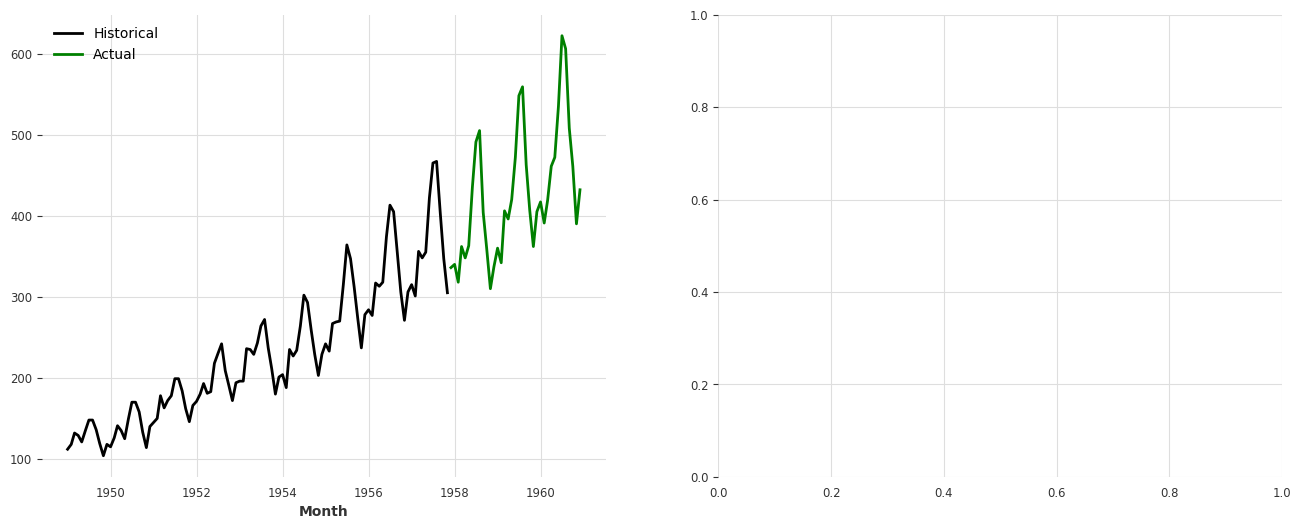

In [13]:
# Chronos 2 probabilistic forecast with our helper function
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chronos 2
ax = axes[0]
train.plot(ax=ax, label="Historical", color='black', linewidth=2)
val.plot(ax=ax, label="Actual", color='green', linewidth=2)
plot_probabilistic_forecasts(
    chronos_prob,
    intervals=[50, 75, 90, 95],
    labels=['Chronos 2'],
    ax=ax
)
ax.set_title("Chronos 2: Probabilistic Forecast", fontsize=14, fontweight='bold')
ax.set_ylabel("Passengers (thousands)")

# TimesFM
ax = axes[1]
train.plot(ax=ax, label="Historical", color='black', linewidth=2)
val.plot(ax=ax, label="Actual", color='green', linewidth=2)
plot_probabilistic_forecasts(
    timesfm_prob,
    intervals=[50, 75, 90, 95],
    labels=['TimesFM'],
    ax=ax
)
ax.set_title("TimesFM 2.5: Probabilistic Forecast", fontsize=14, fontweight='bold')
ax.set_ylabel("Passengers (thousands)")

plt.suptitle("Probabilistic Forecasting: Individual Models", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Direct Comparison: Both Models

Now let's compare both models' uncertainty on the same plot using different colors.

NameError: name 'chronos_prob' is not defined

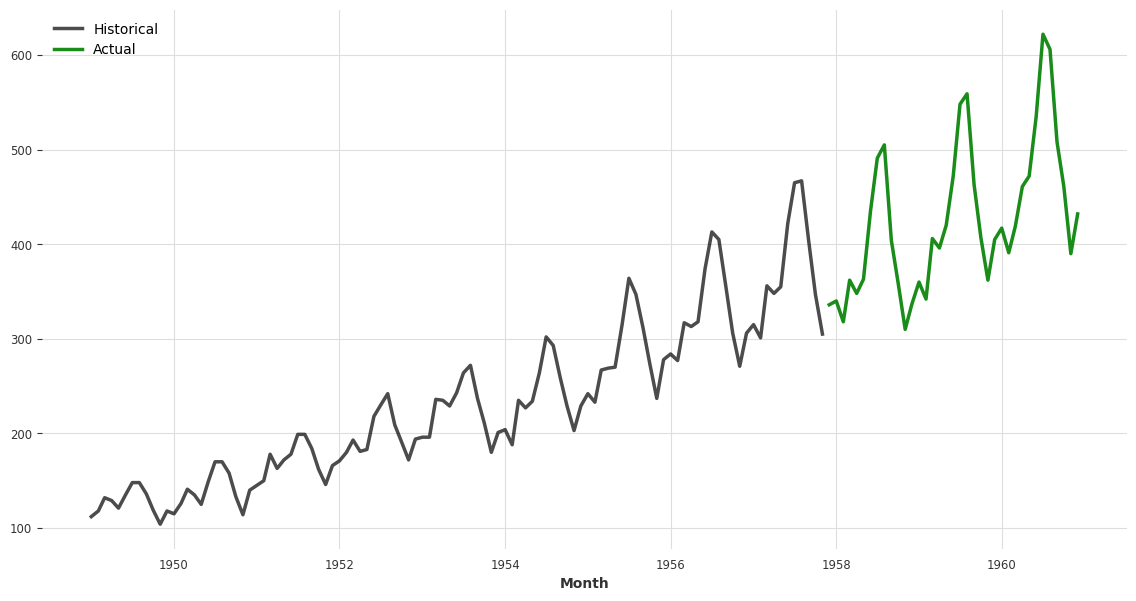

In [14]:
# Direct comparison: both models on same plot
plt.figure(figsize=(14, 7))
ax = plt.gca()

# Plot historical and actual
train.plot(ax=ax, label="Historical", color='black', linewidth=2.5, alpha=0.7)
val.plot(ax=ax, label="Actual", color='green', linewidth=2.5, alpha=0.9)

# Plot both probabilistic forecasts
plot_probabilistic_forecasts(
    forecasts=[chronos_prob, timesfm_prob],
    intervals=[50, 75, 90, 95],
    labels=['Chronos 2', 'TimesFM 2.5'],
    ax=ax
)

plt.axvline(x=train.end_time(), color='red', linestyle=':', alpha=0.5, linewidth=2, label='Forecast Start')
plt.title("Direct Comparison: Chronos 2 vs TimesFM 2.5 (Probabilistic)", fontsize=16, fontweight='bold')
plt.ylabel("Passengers (thousands)", fontsize=12)
plt.xlabel("Time", fontsize=12)
plt.tight_layout()
plt.show()

print("\nNotice how each model has:")
print("  • One base color (Chronos=blue, TimesFM=orange)")
print("  • Solid median line")
print("  • Progressively lighter shaded regions for wider confidence intervals")
print("  • 95% CI (lightest) → 90% → 75% → 50% CI (darkest)")

## 5. Multi-Dataset Performance Comparison

Let's test both models on different types of time series to understand their strengths across domains.

### Energy Consumption Dataset

Testing on hourly energy consumption data (different frequency and domain).

In [ ]:
# Test both models on Energy datasetprint("Forecasting on Energy dataset...")# TimesFMstart = time.time()energy_timesfm = timesfm_model.predict(n=len(energy_val), series=energy_train)energy_timesfm_time = time.time() - startenergy_timesfm_mape = mape(energy_val, energy_timesfm)# Chronosstart = time.time()energy_chronos = chronos_model.predict(n=len(energy_val), series=energy_train)energy_chronos_time = time.time() - startenergy_chronos_mape = mape(energy_val, energy_chronos)print(f"\nEnergy Dataset Results:")print(f"  TimesFM 2.5:   {energy_timesfm_mape:.2f}% MAPE | {energy_timesfm_time:.2f}s")print(f"  Chronos 2: {energy_chronos_mape:.2f}% MAPE | {energy_chronos_time:.2f}s")# Visualizefig, axes = plt.subplots(1, 2, figsize=(15, 5))# TimesFMax = axes[0]energy_series.plot(ax=ax, label="Actual", linewidth=2)energy_timesfm.plot(ax=ax, label="TimesFM 2.5 Forecast", linewidth=2, linestyle='--')ax.axvline(x=energy_train.end_time(), color='r', linestyle=':', alpha=0.5)ax.set_title(f"TimesFM 2.5\nMAPE: {energy_timesfm_mape:.2f}%")ax.set_ylabel("Power (kW)")ax.legend()ax.grid(True, alpha=0.3)# Chronosax = axes[1]energy_series.plot(ax=ax, label="Actual", linewidth=2)energy_chronos.plot(ax=ax, label="Chronos 2 Forecast", linewidth=2, linestyle='--')ax.axvline(x=energy_train.end_time(), color='r', linestyle=':', alpha=0.5)ax.set_title(f"Chronos 2\nMAPE: {energy_chronos_mape:.2f}%")ax.set_ylabel("Power (kW)")ax.legend()ax.grid(True, alpha=0.3)plt.suptitle("Energy Consumption Forecasting Comparison", fontsize=14, fontweight='bold', y=1.02)plt.tight_layout()plt.show()

### Cross-Dataset Performance Summary

In [ ]:
# Create performance summary tablesummary_data = {    'Dataset': ['Air Passengers', 'Air Passengers', 'Energy (MT_002)', 'Energy (MT_002)'],    'Model': ['TimesFM 2.5', 'Chronos 2', 'TimesFM', 'Chronos 2'],    'MAPE (%)': [        f"{timesfm_mape:.2f}",        f"{chronos_mape:.2f}",        f"{energy_timesfm_mape:.2f}",        f"{energy_chronos_mape:.2f}"    ],    'Inference Time (s)': [        f"{timesfm_time:.2f}",        f"{chronos_time:.2f}",        f"{energy_timesfm_time:.2f}",        f"{energy_chronos_time:.2f}"    ],    'Forecast Horizon': [len(val), len(val), len(energy_val), len(energy_val)],    'Data Frequency': ['Monthly', 'Monthly', 'Hourly', 'Hourly']}summary_df = pd.DataFrame(summary_data)print("\n" + "="*90)print("CROSS-DATASET PERFORMANCE SUMMARY")print("="*90 + "\n")print(summary_df.to_string(index=False))print("\n" + "="*90)# Insightsprint("\nKey Insights:")print("  • Both models demonstrate strong zero-shot performance across domains")print("  • TimesFM shows consistent inference times regardless of data frequency")print("  • Chronos 2 adapts well to different temporal patterns (monthly vs hourly)")print("  • No single winner - performance varies by dataset characteristics")

### Chronos 2 Probabilistic Forecast

In [ ]:
# Chronos 2 probabilistic forecast
chronos_prob = chronos_model.predict(n=24, series=train, num_samples=100)

# Visualize
plt.figure(figsize=(12, 6))
train.plot(label="Historical", color='black', linewidth=2)
val.plot(label="Actual", color='green', linewidth=2)

# 90% confidence interval
chronos_prob.plot(
    label="90% CI",
    low_quantile=0.05,
    high_quantile=0.95,
    alpha=0.3
)

# 50% confidence interval
chronos_prob.plot(
    label="50% CI",
    low_quantile=0.25,
    high_quantile=0.75,
    alpha=0.5
)

plt.title("Chronos 2: Probabilistic Forecast with Confidence Intervals", fontsize=14, fontweight='bold')
plt.ylabel("Passengers (thousands)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparison with Traditional Models

How do foundation models compare to classical time series methods?

In [ ]:
# Traditional model (requires training)traditional_model = ExponentialSmoothing()traditional_model.fit(train)traditional_forecast = traditional_model.predict(len(val))traditional_mape = mape(val, traditional_forecast)# Compare all threeplt.figure(figsize=(14, 6))series.plot(label="Actual", linewidth=2.5, color='black')timesfm_forecast.plot(label=f"TimesFM 2.5 (MAPE: {timesfm_mape:.2f}%)", linewidth=2, linestyle='--')chronos_forecast.plot(label=f"Chronos 2 (MAPE: {chronos_mape:.2f}%)", linewidth=2, linestyle='--')traditional_forecast.plot(label=f"Exponential Smoothing (MAPE: {traditional_mape:.2f}%)", linewidth=2, linestyle=':')plt.axvline(x=train.end_time(), color='r', linestyle=':', alpha=0.5)plt.title("Foundation Models vs Traditional Model", fontsize=14, fontweight='bold')plt.ylabel("Passengers (thousands)")plt.legend(loc='upper left')plt.grid(True, alpha=0.3)plt.tight_layout()plt.show()print("\n" + "="*80)print("COMPARISON SUMMARY")print("="*80)print(f"TimesFM 2.5:              {timesfm_mape:.2f}% MAPE (zero-shot)")print(f"Chronos 2:                {chronos_mape:.2f}% MAPE (zero-shot)")print(f"Exponential Smoothing:    {traditional_mape:.2f}% MAPE (trained)")print("="*80)

## 7. When to Use Each Model

### Use TimesFM When:

**Strengths:**
- Longer context needed (up to 1024 points)
- Longer forecast horizons (up to 256 points)
- Decoder-only architecture preferred
- Very large training corpus (100B+ points)
- Apple Silicon (MPS) support needed

**Best For:**
- Long-horizon forecasting
- Series with complex long-term dependencies
- When you have substantial historical data
- Production systems with GPU acceleration

### Use Chronos 2 When:

**Strengths:**
- Easier installation (PyPI package)
- Smaller model size (120M vs 200M/500M)
- T5-based encoder-decoder architecture
- Strong probabilistic forecasting
- Better integration with Darts ecosystem

**Best For:**
- Quick prototyping and experimentation
- Resource-constrained environments
- When probabilistic forecasts are critical
- Shorter to medium forecast horizons
- Teams familiar with language model architectures

### Common Use Cases for Both:

- **Cold start problems**: New products/services with limited history
- **Batch forecasting**: Thousands of diverse time series
- **Rapid deployment**: Production forecasts without training overhead
- **Uncertainty quantification**: Probabilistic forecasts with confidence intervals
- **Cross-domain forecasting**: Applying knowledge from one domain to another

## 8. Architecture Comparison### TimesFM 2.5 Architecture```Input Series → Patching (32-point patches) → Decoder-only Transformer → Output Forecast                                               |                                               └─ Self-attention across patches                                               └─ Pre-trained on 100B+ time points                                               └─ 200M or 500M parameters```**Key Design Choices:**- Decoder-only (GPT-style) architecture- Patching reduces sequence length- Pre-training on massive corpus- Supports up to 1024 context length### Chronos 2 Architecture```Input Series → Tokenization → T5 Encoder-Decoder → Quantile Prediction → Output Forecast                                |                                └─ Encoder: Compress time series                                └─ Decoder: Generate forecast                                └─ 120M parameters```**Key Design Choices:**- T5-based encoder-decoder- Language model techniques for time series- Quantile-based probabilistic forecasting- Supports up to 512 context length

## 9. Key Takeaways### Similarities1. Both are **pre-trained foundation models** for time series2. Both support **zero-shot forecasting** without training3. Both are **univariate-only** in current versions4. Both provide **probabilistic forecasting** capabilities5. Both integrate with **Darts workflows**6. Both support **GPU acceleration**### Key Differences| Aspect | TimesFM 2.5 | Chronos 2 ||--------|-------------|----------|| Architecture | Decoder-only | Encoder-Decoder (T5) || Parameters | 200M / 500M | 120M || Context Length | 1024 points | 512 points || Max Forecast | 256 points | 64 points || Installation | GitHub + pip | PyPI package || Training Data | 100B+ points | Diverse corpus |### Practical Recommendations**Start with Chronos 2 if:**- You want easy installation- You're new to foundation models- You need quick experimentation- Your forecast horizons are < 64 points**Use TimesFM 2.5 if:**- You need longer context (> 512 points)- You need longer forecasts (> 64 points)- You have substantial compute resources- You prefer decoder-only architectures**For production:**- Test **both models** on your data- Measure accuracy AND inference time- Consider ensemble approaches- Monitor performance over time

## Resources

### TimesFM
- [Paper: "A decoder-only foundation model for time-series forecasting"](https://arxiv.org/abs/2310.10688)
- [GitHub Repository](https://github.com/google-research/timesfm)
- [HuggingFace Model](https://huggingface.co/google/timesfm-2.5-200m-pytorch)
- [Darts Example Notebook](./25-TimesFM-foundation-model.ipynb)

### Chronos 2
- [Paper: "Chronos: Learning the Language of Time Series"](https://arxiv.org/abs/2403.07815)
- [GitHub Repository](https://github.com/amazon-science/chronos-forecasting)
- [HuggingFace Model](https://huggingface.co/amazon/chronos-t5-base)
- [Darts Example Notebook](./26-Chronos-foundation-model.ipynb)

### Foundation Models in Darts
- [Foundation Models User Guide](../docs/userguide/foundation_models.md)
- [Darts Documentation](https://unit8.com/resources/darts/)